In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [105]:
df = pd.read_csv("solar_system.csv")
print(df)

                      Attribute Mercury    Venus  Earth   Moon   Mars  \
0                Mass (10^24kg)   0.330     4.87   5.97  0.073  0.642   
1                 Diameter (km)    4879    12104  12756   3475   6792   
2              Density (kg/m^3)    5429     5243   5514   3340   3934   
3               Gravity (m/s^2)     3.7      8.9    9.8    1.6    3.7   
4        Escape Velocity (km/s)     4.3     10.4   11.2    2.4    5.0   
5       Rotation Period (hours)  1407.6  -5832.5   23.9  655.7   24.6   
6         Length of Day (hours)  4222.6   2802.0   24.0  708.7   24.7   
7   Distance from Sun (10^6 km)    57.9    108.2  149.6  0.384  228.0   
8          Perihelion (10^6 km)    46.0    107.5  147.1  0.363  206.7   
9            Aphelion (10^6 km)    69.8    108.9  152.1  0.406  249.3   
10        Orbital Period (days)    88.0    224.7  365.2   27.3  687.0   
11      Orbital Velocity (km/s)    47.4     35.0   29.8    1.0   24.1   
12    Orbital Inclination (deg)     7.0      3.4   

In [94]:
df.shape # 20 rows, 11 columns

(20, 11)

In [95]:
print(df.head())
print(df.tail())

                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18             Ring System?    

In [106]:
print(df['Attribute'])

0                  Mass (10^24kg)
1                   Diameter (km)
2                Density (kg/m^3)
3                 Gravity (m/s^2)
4          Escape Velocity (km/s)
5         Rotation Period (hours)
6           Length of Day (hours)
7     Distance from Sun (10^6 km)
8            Perihelion (10^6 km)
9              Aphelion (10^6 km)
10          Orbital Period (days)
11        Orbital Velocity (km/s)
12      Orbital Inclination (deg)
13           Orbital Eccentricity
14       Obliquity to Orbit (deg)
15           Mean Temperature (C)
16        Surface Pressure (bars)
17                Number of Moons
18                   Ring System?
19         Global Magnetic Field?
Name: Attribute, dtype: object


In [97]:
print(df.columns)

Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')


In [98]:
orbit_period = df.iloc[10]
print(orbit_period)

Attribute    Orbital Period (days)
Mercury                       88.0
Venus                        224.7
Earth                        365.2
Moon                          27.3
Mars                         687.0
Jupiter                       4331
Saturn                       10747
Uranus                       30589
Neptune                      59800
Pluto                        90560
Name: 10, dtype: object


In [99]:
perihelion = df.iloc[8, 1:].astype(float)
print(perihelion)

Mercury      46.000
Venus       107.500
Earth       147.100
Moon          0.363
Mars        206.700
Jupiter     740.600
Saturn     1357.600
Uranus     2732.700
Neptune    4471.100
Pluto      4436.800
Name: 8, dtype: float64


In [100]:
aphelion = df.iloc[9, 1:].astype(float)
print(aphelion)

Mercury      69.800
Venus       108.900
Earth       152.100
Moon          0.406
Mars        249.300
Jupiter     816.400
Saturn     1506.500
Uranus     3001.400
Neptune    4558.900
Pluto      7375.900
Name: 9, dtype: float64


In [101]:
# Perihelion is the point in a star/planet/something in space where it is closest to the Sun.
# Aphelion is the opposite, the point in which something in orbit is furthers from the Sun.
# Semi-major axis is one-half of the longest diameter of an ellipse.

In [107]:
semi_major_axis = (perihelion + aphelion) / 2
print(semi_major_axis)
semi_major_axis_list = semi_major_axis.tolist()
print(semi_major_axis_list)

Mercury      57.9000
Venus       108.2000
Earth       149.6000
Moon          0.3845
Mars        228.0000
Jupiter     778.5000
Saturn     1432.0500
Uranus     2867.0500
Neptune    4515.0000
Pluto      5906.3500
dtype: float64
[57.9, 108.2, 149.6, 0.3845, 228.0, 778.5, 1432.05, 2867.05, 4515.0, 5906.35]


In [108]:
# use .T to transpose
semi_major_axis_df = pd.DataFrame(semi_major_axis).T # makes semi_major_axis into a dataframe, and .T transposes the column to a row
print(semi_major_axis_df)
df = pd.concat([df, semi_major_axis_df], ignore_index = True) # adds the row to the dataframe, but is currently lacking a name
print(df)

   Mercury  Venus  Earth    Moon   Mars  Jupiter   Saturn   Uranus  Neptune  \
0     57.9  108.2  149.6  0.3845  228.0    778.5  1432.05  2867.05   4515.0   

     Pluto  
0  5906.35  
                      Attribute Mercury    Venus  Earth    Moon   Mars  \
0                Mass (10^24kg)   0.330     4.87   5.97   0.073  0.642   
1                 Diameter (km)    4879    12104  12756    3475   6792   
2              Density (kg/m^3)    5429     5243   5514    3340   3934   
3               Gravity (m/s^2)     3.7      8.9    9.8     1.6    3.7   
4        Escape Velocity (km/s)     4.3     10.4   11.2     2.4    5.0   
5       Rotation Period (hours)  1407.6  -5832.5   23.9   655.7   24.6   
6         Length of Day (hours)  4222.6   2802.0   24.0   708.7   24.7   
7   Distance from Sun (10^6 km)    57.9    108.2  149.6   0.384  228.0   
8          Perihelion (10^6 km)    46.0    107.5  147.1   0.363  206.7   
9            Aphelion (10^6 km)    69.8    108.9  152.1   0.406  249.3   
1

In [109]:
df.loc[20, "Attribute"] = 'Semi Major Axis (km)'
print(df)
print(type(df))

                      Attribute Mercury    Venus  Earth    Moon   Mars  \
0                Mass (10^24kg)   0.330     4.87   5.97   0.073  0.642   
1                 Diameter (km)    4879    12104  12756    3475   6792   
2              Density (kg/m^3)    5429     5243   5514    3340   3934   
3               Gravity (m/s^2)     3.7      8.9    9.8     1.6    3.7   
4        Escape Velocity (km/s)     4.3     10.4   11.2     2.4    5.0   
5       Rotation Period (hours)  1407.6  -5832.5   23.9   655.7   24.6   
6         Length of Day (hours)  4222.6   2802.0   24.0   708.7   24.7   
7   Distance from Sun (10^6 km)    57.9    108.2  149.6   0.384  228.0   
8          Perihelion (10^6 km)    46.0    107.5  147.1   0.363  206.7   
9            Aphelion (10^6 km)    69.8    108.9  152.1   0.406  249.3   
10        Orbital Period (days)    88.0    224.7  365.2    27.3  687.0   
11      Orbital Velocity (km/s)    47.4     35.0   29.8     1.0   24.1   
12    Orbital Inclination (deg)     7.

In [110]:
print(df.shape) # 21 rows, 11 columns!

(21, 11)


[8.8000e+01 2.2470e+02 3.6520e+02 2.7300e+01 6.8700e+02 4.3310e+03
 1.0747e+04 3.0589e+04 5.9800e+04 9.0560e+04]


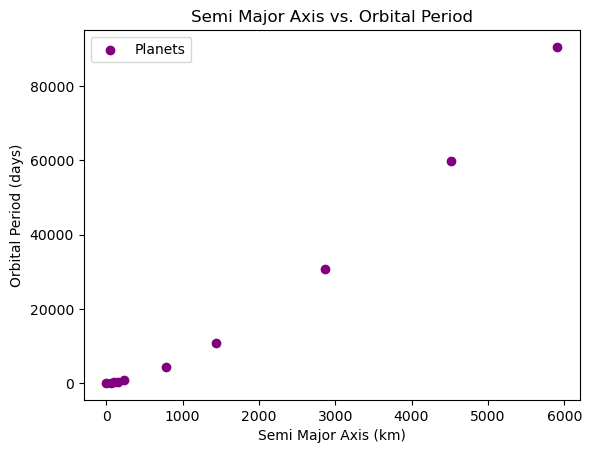

In [139]:
x = df.iloc[20, 1:].to_numpy(dtype=float) # use .iloc[] to index a specific value in a dataframe, here we are indexing semi major axis
y = df.iloc[10, 1:].to_numpy(dtype=float) # indexed orbital period

print(x)
print(y)

plt.figure()
plt.scatter(x, y, label = 'Planets', color = 'purple')
plt.xlabel('Semi Major Axis (km)')
plt.ylabel('Orbital Period (days)')
plt.title('Semi Major Axis vs. Orbital Period')
plt.legend()
plt.show()

In [128]:
def keplers_third_law(a, m):
    return m * a ** 1.5

In [142]:
p0 = [1]

popt, pcov = curve_fit(keplers_third_law, x, y, p0 = p0)
m_fit = popt
print(m_fit)



residuals = y - keplers_third_law(x, m_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
print(chi2_reduced)

[0.19879982]
41276.70608939304


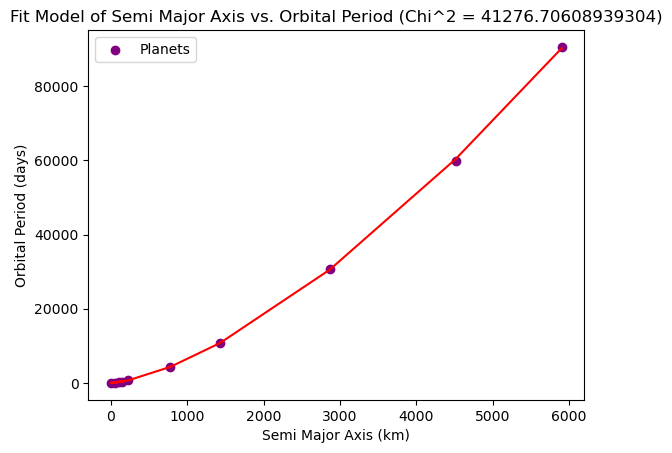

In [145]:
plt.figure()
plt.scatter(x, y, label = 'Planets', color = 'purple')
plt.plot(x, keplers_third_law(x, *popt), color = 'red')
plt.xlabel('Semi Major Axis (km)')
plt.ylabel('Orbital Period (days)')
plt.title('Fit Model of Semi Major Axis vs. Orbital Period (Chi^2 = 41276.70608939304)')
plt.legend()
plt.show()

In [146]:
df.to_csv("kepler_csv", index = False)